# SHAP Feature Attribution Analysis — SC 2026

Analyzes which Darshan features drive each bottleneck dimension prediction.
Validates that SHAP top features match domain knowledge.

**Expected runtime**: < 1 minute (loads pre-computed SHAP values)

In [1]:
import pickle, numpy as np
import shap
import matplotlib.pyplot as plt

DIMS = ['access_granularity', 'metadata_intensity', 'parallelism_efficiency',
        'access_pattern', 'interface_choice', 'file_strategy',
        'throughput_utilization', 'healthy']

## 1. Load Pre-Computed SHAP Values

In [2]:
with open('../paper/figures/shap/shap_values.pkl', 'rb') as f:
    data = pickle.load(f)

shap_dict = data['shap_dict']
feature_names = data['feature_names']
X_sample = data['X_sample']

print(f'Dimensions: {len(shap_dict)}')
print(f'Features: {len(feature_names)}')
print(f'Samples: {len(X_sample)}')

Dimensions: 8
Features: 157
Samples: 436


## 2. Feature-Label Heatmap (Main Paper Figure)

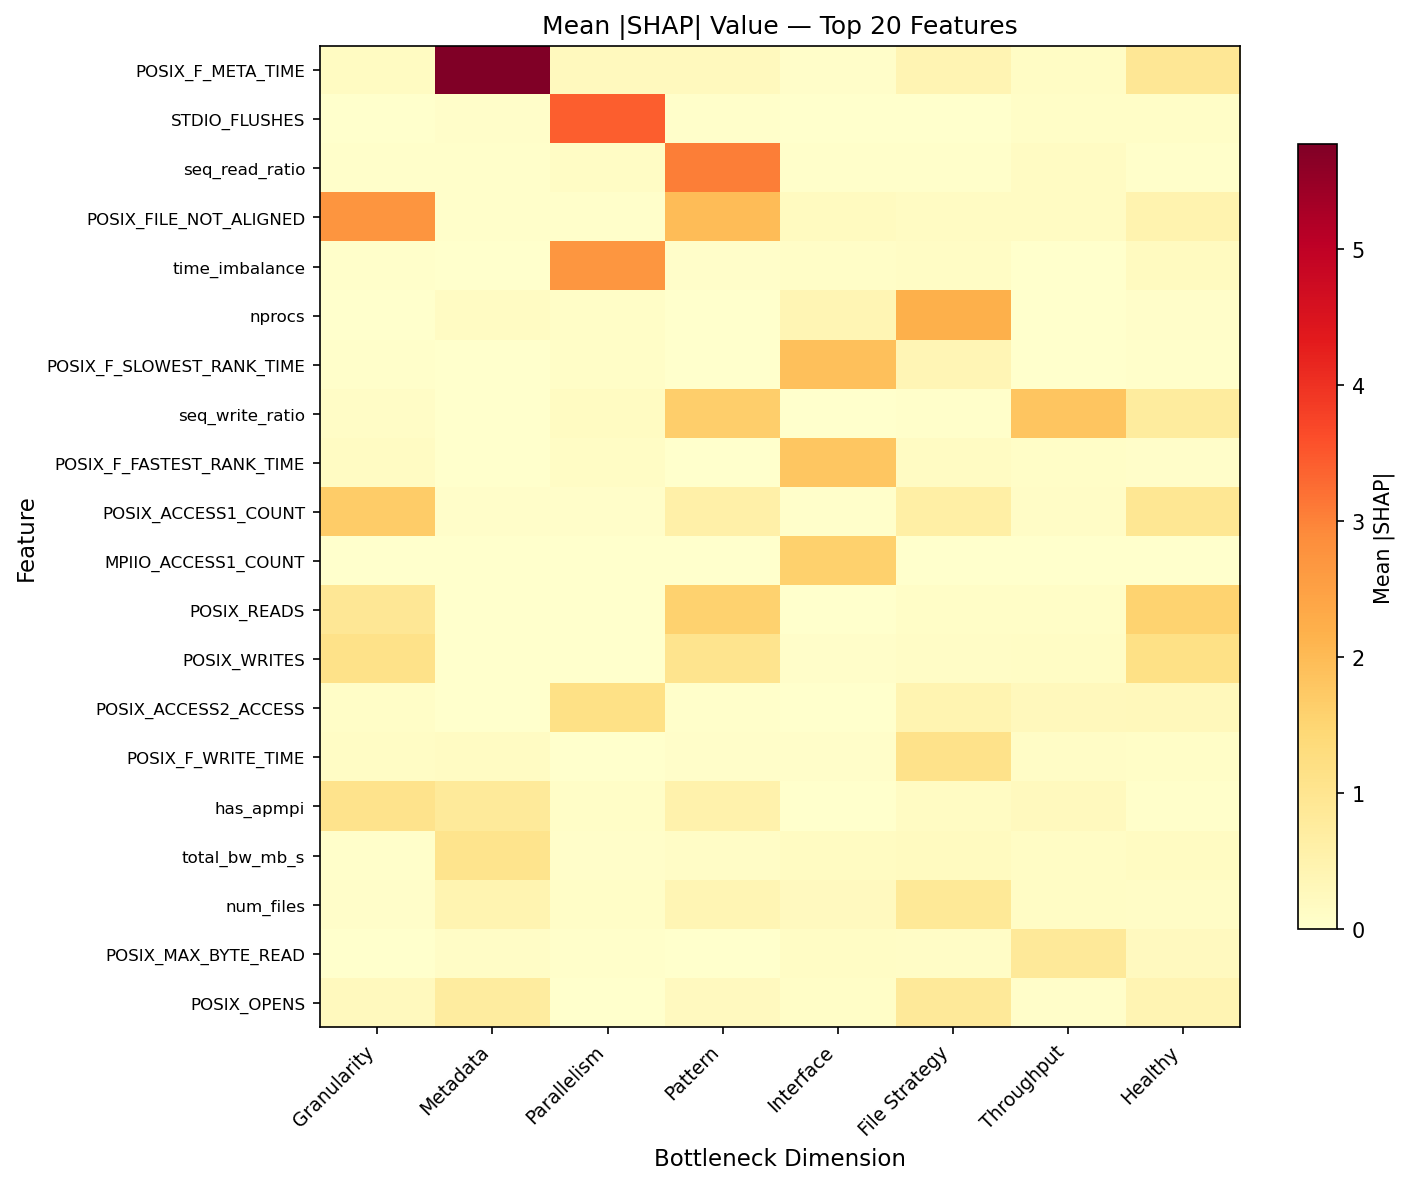

In [3]:
# Show pre-generated heatmap
from IPython.display import Image
Image(filename='../paper/figures/shap/fig_shap_heatmap.png', width=800)

## 3. Top Features Per Dimension

In [4]:
for dim in DIMS:
    if dim not in shap_dict:
        continue
    mean_abs = np.abs(shap_dict[dim]).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-5:][::-1]
    print(f'\n{dim}:')
    for idx in top_idx:
        print(f'  {feature_names[idx]:35s} mean|SHAP|={mean_abs[idx]:.4f}')


access_granularity:
  POSIX_FILE_NOT_ALIGNED              mean|SHAP|=2.7158
  POSIX_ACCESS1_COUNT                 mean|SHAP|=1.6883
  POSIX_WRITES                        mean|SHAP|=1.1128
  has_apmpi                           mean|SHAP|=1.0746
  POSIX_READS                         mean|SHAP|=0.9248

metadata_intensity:
  POSIX_F_META_TIME                   mean|SHAP|=5.7775
  total_bw_mb_s                       mean|SHAP|=1.0564
  has_apmpi                           mean|SHAP|=0.8129
  POSIX_OPENS                         mean|SHAP|=0.7396
  mem_misalign_ratio                  mean|SHAP|=0.6822

parallelism_efficiency:
  STDIO_FLUSHES                       mean|SHAP|=3.4090
  time_imbalance                      mean|SHAP|=2.6898
  POSIX_ACCESS2_ACCESS                mean|SHAP|=1.1676
  file_misalign_ratio                 mean|SHAP|=0.8239
  STDIO_READS                         mean|SHAP|=0.5908

access_pattern:
  seq_read_ratio                      mean|SHAP|=3.0537
  POSIX_FILE_NOT_ALI

## 4. Per-Label Beeswarm Plots

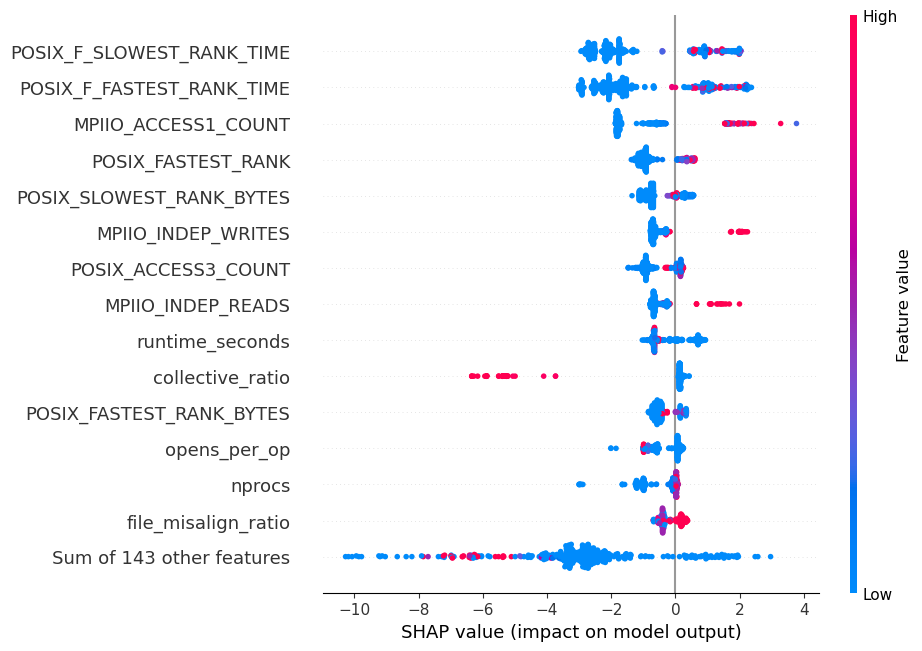

In [5]:
# Show beeswarm for interface_choice (most interesting)
dim = 'interface_choice'
sv = shap_dict[dim]
explanation = shap.Explanation(values=sv, data=X_sample, feature_names=feature_names)
shap.plots.beeswarm(explanation, max_display=15, show=True)

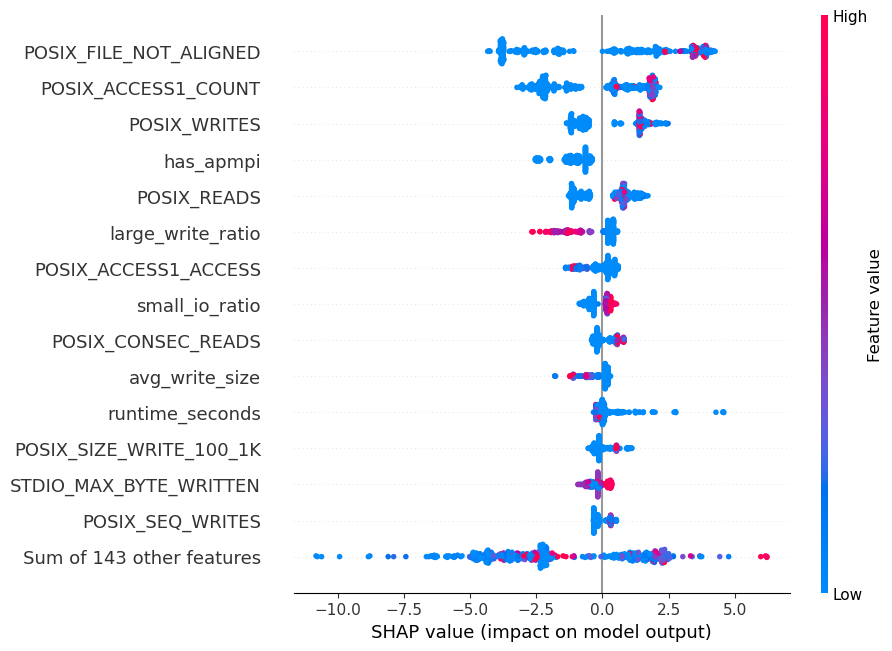

In [6]:
# Show beeswarm for access_granularity
dim = 'access_granularity'
sv = shap_dict[dim]
explanation = shap.Explanation(values=sv, data=X_sample, feature_names=feature_names)
shap.plots.beeswarm(explanation, max_display=15, show=True)